# Predictive tests for the sufficiency null — standalone

**Part I (cells below, through the features dictionary)** is copied verbatim from `Regressions_REVISION.ipynb`, cells 0–29: data loading, merges, and the `features` dictionary. Nothing has been changed.

**Part II** adds the Clark–West, top-decile precision and Diebold–Mariano tests.

Update `DATA_PATH` below if your Dropbox path differs, then run all.

## 0. Imports

In [1]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.api import OLS, add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from scipy import stats
from scipy.optimize import curve_fit

import altair as alt
alt.data_transformers.disable_max_rows()

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)

## 1. Configuration

> **Edit this cell to change variables, shock sizes, or asset groups.**

In [2]:
# ── Data path ────────────────────────────────────────────────
DATA_PATH = '../data/'

## 2. Data Loading & Preparation

Run once. Produces `regr_pool_users` — the master dataset used by both crypto and stablecoin sections.

In [3]:
# ── Load raw files ───────────────────────────────────────────
print("Loading data...")

dr = pd.read_csv(DATA_PATH + 'liquidation.csv')
dr['shockAsset'] = dr['shock'].str.replace('c', '', regex=False)
dr['asset_group'] = np.where(
    dr['shockAsset'].isin(['ETH', 'WBTC']), 'Crypto',
    np.where(dr['shockAsset'].isin(['USDC', 'DAI']), 'Stablecoin', 'Other')
)

pool_stats = pd.read_csv(DATA_PATH + 'pool_statistics_with_cf.csv')
pool_stats['shockAsset'] = pool_stats['node'].str.replace('c', '', regex=False)

net_stats = pd.read_csv(DATA_PATH + 'network_statistics.csv')

cen_pool = pd.read_csv(DATA_PATH + 'pool_centralities.csv')
cen_pool['shockAsset'] = cen_pool['node'].str.replace('c', '', regex=False)

all_n = pd.read_csv(DATA_PATH + 'shockAsset_lenders_borrowers_new.csv').sort_values('date')
all_n['date'] = pd.to_datetime(all_n['date'])
all_n['shockAsset'] = all_n['symbol'].str.replace('c', '', regex=False)

print("Done.")

Loading data...
Done.


In [4]:
pool_stats[['date', 'shockAsset', 'pctDeposit', 'pctBorrow', 'pctEquity']].rename(columns={
      'pctDeposit': 'shareDeposit',                                                          
      'pctBorrow':  'shareBorrow',                                                           
      'pctEquity':  'shareEquity'                                                            
  })           

,date,shockAsset,shareDeposit,shareBorrow,shareEquity
0,2020-01-01,BAT,0.006680,2.289820e-03,0.000516
1,2020-01-01,DAI,0.159804,3.421849e-01,0.571235
2,2020-01-01,ETH,0.379802,1.182162e-02,0.003153
3,2020-01-01,REP,0.112051,1.971574e-03,0.000364
4,2020-01-01,SAI,0.048236,7.874537e-02,0.099439
...,...,...,...,...,...
24332,2024-06-15,USDP,0.000401,1.561052e-03,0.000150
24333,2024-06-15,USDT,0.181990,5.791646e-01,0.088551
24334,2024-06-15,WBTC,0.291670,4.308659e-03,0.000017
24335,2024-06-15,YFI,0.000083,7.408324e-08,0.000061


In [5]:
# ── Merge pool stats + bad debt ──────────────────────────────
regr_pool = pd.merge(pool_stats, dr, on=['date', 'shockAsset'], how='left')
regr_pool['date']  = pd.to_datetime(regr_pool['date'], errors='coerce')
regr_pool['year']  = regr_pool['date'].dt.year
regr_pool['month'] = regr_pool['date'].dt.month

regr_pool['assets']          = regr_pool['in_weight'] + regr_pool['ext_assets']
#regr_pool['log_assets']      = np.log1p(regr_pool['assets'])
regr_pool['equity_share']    = regr_pool['equity']     / regr_pool['assets']
regr_pool['extassets_share'] = regr_pool['ext_assets'] / regr_pool['assets']

total_assets = (regr_pool.groupby('date')['assets'].sum()
                .reset_index(name='total_assets'))
regr_pool = regr_pool.merge(total_assets, on='date', how='left')

regr_pool['size_share']    = regr_pool['assets']      / regr_pool['total_assets']
# regr_pool['self_borrow']   = (regr_pool['pctSelfBorrow'] * regr_pool['in_weight']) / regr_pool['total_assets']
regr_pool['self_borrow_2'] = (regr_pool['pctSelfBorrow'] * regr_pool['in_weight']) / regr_pool['assets']

# ── Merge centralities + network stats ───────────────────────
for df in [regr_pool, cen_pool, net_stats]:
    df['date'] = pd.to_datetime(df['date'])

cen_net         = cen_pool.merge(net_stats, on='date', how='left')
regr_pool_final = regr_pool.merge(cen_net, on=['date', 'shockAsset'], how='left')

# ── Dependent and independent variables ──────────────────────
#regr_pool_final['TD']                = regr_pool_final['T'] + regr_pool_final['D']
#regr_pool_final['log_out_weight']    = np.log(regr_pool_final['out_weight'])
regr_pool_final['utilization_ratio'] = 1 - (
    regr_pool_final['ext_assets'] /
    (regr_pool_final['ext_assets'] + regr_pool_final['in_weight'])
)
#regr_pool_final['log_totCollateral'] = np.log(regr_pool_final['totCollateral'])
#regr_pool_final['log_B']             = np.log(regr_pool_final['B'])
regr_pool_final['share_B']           = regr_pool_final['B'] / regr_pool_final['assets']
#regr_pool_final['log_share_B']       = np.log(regr_pool_final['share_B'])
regr_pool_final['share_T']           = (regr_pool_final['T'] - regr_pool_final['Tp']) / regr_pool_final['assets']
regr_pool_final['delta_T']           = (regr_pool_final['T'] - regr_pool_final['Tp'])

# ── Merge user/collateral neighbourhood features ─────────────
regr_pool_users = regr_pool_final.merge(all_n, on=['date', 'shockAsset'], how='left')

# Log-transform skewed neighbourhood variables
# Add new log-transforms here if you add new raw variables above
#for log_col, raw_col in [
#    ('log_collaterals-in_weight-sum',   'collaterals-in_weight-sum'),
#    ('log_collaterals-equity-wavg',     'collaterals-equity-wavg'),
#    ('log_collaterals-out_weight-wavg', 'collaterals-out_weight-wavg'),
#    ('log_collaterals-out_degree-wavg', 'collaterals-out_degree-wavg'),
#    ('log_borrowers-out_weight-wavg',   'borrowers-out_weight-wavg'),
#    ('log_borrowers-equity-wavg',       'borrowers-equity-wavg'),
#]:
#    regr_pool_users[log_col] = np.log(regr_pool_users[raw_col])

regr_pool_users['asset_group'] = np.where(
    regr_pool_users['shockAsset'].isin(['ETH', 'WBTC']), 'Crypto',
    np.where(regr_pool_users['shockAsset'].isin(['USDC', 'DAI']),
             'Stablecoin', 'Other')
)

print(f"Master dataset ready: {regr_pool_users.shape}")
print(f"Assets: {sorted(regr_pool_users['shockAsset'].unique())}")

Master dataset ready: (96508, 415)
Assets: ['AAVE', 'BAT', 'COMP', 'DAI', 'ETH', 'FEI', 'LINK', 'REP', 'SAI', 'SUSHI', 'TUSD', 'UNI', 'USDC', 'USDP', 'USDT', 'WBTC', 'YFI', 'ZRX']


In [6]:
print(regr_pool_users.columns.tolist())

['date', 'node_x', 'collateralFactor', 'in_degree', 'in_weight', 'in_weight_hhi', 'out_degree', 'out_weight', 'out_weight_hhi', 'in_out_ratio', 'ext_assets', 'equity', 'selfBorrowUSD', 'pctSelfBorrow_x', 'usedCollateralUSD', 'pctUsedCollateral', 'pctDeposit', 'pctBorrow', 'pctEquity', 'shockAsset', 'shock', 'size', 'C', 'D', 'T', 'E', 'Cp', 'Dp', 'Tp', 'B', 'Ep', 'liquidated_nbd', 'liquidated_bd', 'seized_nbd', 'seized_bd', 'asset_group', 'year', 'month', 'assets', 'equity_share', 'extassets_share', 'total_assets', 'size_share', 'self_borrow_2', 'node_y', 'eigenvector', 'pagerank', 'hub', 'authority', 'core', 'katz', 'laplacian', 'betweeness', 'closeness', 'borrowing', 'funding', 'eigenvector_scaled', 'pagerank_scaled', 'hub_scaled', 'authority_scaled', 'core_scaled', 'katz_scaled', 'laplacian_scaled', 'betweeness_scaled', 'closeness_scaled', 'borrowing_scaled', 'funding_scaled', 'nPool', 'nUsers', 'nPureLenders', 'nBorrowers', 'nPureLenders100', 'nBorrowers100', 'nNewPureLenders', 'nN

# 2. ANALYSIS OF LIQUIDITY

# 2.1 Descriptive Statistics

In [7]:
lp = pd.read_csv(DATA_PATH + 'liquidation_pools.csv')
lp['shockAsset'] = lp['shock'].str.replace('c', '', regex=False)
lp['otherAsset'] = lp['symbol'].str.replace('c', '', regex=False)

lp['date'] = pd.to_datetime(lp['date'])

In [8]:
# Merge Liquidation_pools with other dataset

lp_own = lp[lp['shockAsset'] == lp['otherAsset']].copy()

rename_map = {
    'C':  'C_pool',
    'D':  'D_pool',
    'T':  'T_pool',
    'E':  'E_pool',
    'Cp': 'Cp_pool',
    'Dp': 'Dp_pool',
    'Tp': 'Tp_pool',
    'B':  'B_pool',
    'Ep': 'Ep_pool',
}
lp_own = lp_own.rename(columns=rename_map)

lp_own = lp_own.rename(columns={'date_pool': 'date'})


In [9]:
final = pd.merge(regr_pool_users, lp_own, on=['date', 'size', 'shockAsset'], how='left')
final['shareT_pool'] = (final['T_pool'] - final['Tp_pool']) / final['assets']

### Structural Break

In [10]:
# WARNING: Set arbitrary break date !
break_date = pd.to_datetime('2021-01-01')  # or use this fixed date if you prefer

In [11]:
lp = pd.read_csv(DATA_PATH + 'liquidation_pools.csv')
lp['shockAsset'] = lp['shock'].str.replace('c', '', regex=False)
lp['otherAsset'] = lp['symbol'].str.replace('c', '', regex=False)

lp['date'] = pd.to_datetime(lp['date'])

In [12]:
new_health = pd.read_csv(DATA_PATH + 'shockAsset_collateral_filtered.csv')
new_health['date'] = pd.to_datetime(new_health['date'])

In [13]:
merge_keys = ['date', 'shockAsset', 'size']
common_cols = [c for c in new_health.columns 
               if c in final.columns and c not in merge_keys]
print(f"Columns to be replaced: {common_cols}")
print(f"New columns from new_health: {[c for c in new_health.columns if c not in final.columns and c not in merge_keys]}")


Columns to be replaced: ['collaterals-in_weight-count', 'collaterals-out_weight-count', 'collaterals-depositUSD-sum', 'collaterals-in_degree-sum', 'collaterals-in_weight-sum', 'collaterals-in_weight_hhi-sum', 'collaterals-out_degree-sum', 'collaterals-out_weight-sum', 'collaterals-out_weight_hhi-sum', 'collaterals-in_out_ratio-sum', 'collaterals-ext_assets-sum', 'collaterals-equity-sum', 'collaterals-selfBorrowUSD-sum', 'collaterals-pctSelfBorrow-sum', 'collaterals-usedCollateralUSD-sum', 'collaterals-pctUsedCollateral-sum', 'collaterals-maxCollateralUSD-sum', 'collaterals-health-sum', 'collaterals-pctDeposit-sum', 'collaterals-debtToCollateral-sum', 'collaterals-depositUSD-avg', 'collaterals-in_degree-avg', 'collaterals-in_weight-avg', 'collaterals-in_weight_hhi-avg', 'collaterals-out_degree-avg', 'collaterals-out_weight-avg', 'collaterals-out_weight_hhi-avg', 'collaterals-in_out_ratio-avg', 'collaterals-ext_assets-avg', 'collaterals-equity-avg', 'collaterals-selfBorrowUSD-avg', 'coll

In [14]:
final_updated = (final
                 .drop(columns=common_cols)
                 .merge(new_health.assign(shockAsset=new_health['symbol'].str.replace('c', '', regex=False))
                                  .drop(columns=['symbol']),
                        on=['date', 'shockAsset'], how='left'))

print(f"Original shape: {final.shape}")
print(f"Updated shape:  {final_updated.shape}")
print(f"Unmatched rows: {final_updated['collaterals-health-wavg'].isna().sum()}")


Original shape: (96508, 432)
Updated shape:  (288846, 433)
Unmatched rows: 334


### 3. Features' selection, Analysis of liquidation, Regressions 

### 3.1 Features' dictionary

In [15]:
# Create dictionary of column groups for pool-level features

pool_cols = {
    'own': [
        'ext_assets', 'equity', 
        # 'selfBorrowUSD', 'pctSelfBorrow_x', 'self_borrow',
        'usedCollateralUSD', 'pctUsedCollateral', 'pctDeposit', 'pctBorrow', 'pctEquity',
        'assets', 'log_assets', 'equity_share', 'extassets_share',
        'size_share',  'self_borrow_2',
        'log_out_weight', 'utilization_ratio', 'C_pool', 'D_pool', 'T_pool', 'E_pool', 'collateralFactor', 
         'in_degree', 'in_weight', 'in_weight_hhi', 'out_degree', 'out_weight', 'out_weight_hhi', 'in_out_ratio' 
    ],
    'centrality': [
        'eigenvector', 'pagerank', 'hub', 'authority', 'core',
        'katz', 'laplacian', 'betweeness', 'closeness', 'borrowing', 'funding',
        'eigenvector_scaled', 'pagerank_scaled', 'hub_scaled', 'authority_scaled',
        'core_scaled', 'katz_scaled', 'laplacian_scaled', 'betweeness_scaled',
        'closeness_scaled', 'borrowing_scaled', 'funding_scaled',
        'density', 'reciprocity', 'biDensity', 'biAvgClustering', 'biAvgLatapyClustering'
    ],
    'aggregate': [
        'nPool', 'nUsers', 'nPureLenders', 'nBorrowers',
        'nPureLenders100', 'nBorrowers100',
        'nNewPureLenders', 'nNewBorrowers', 'nNewPureLenders100', 'nNewBorrowers100',
        'totDeposit', 'totPureLender', 'totCollateral', 'totBorrow', 'utilization',
        'totNewDeposit', 'totNewBorrow', 'newUtilization',
        'nDeposit', 'nBorrow', 'nDeposit100', 'nBorrow100',
        'nNewDeposit', 'nNewBorrow', 'nNewDeposit100', 'nNewBorrow100',
        'C', 'D', 'T', 'E', 'TD', 'total_assets'
    ],
    'cross_pool': [
        c for c in final.columns if c.startswith('pools_')
    ]
}

# Verify all columns exist in final
for group, cols in pool_cols.items():
    missing = [c for c in cols if c not in final.columns]
    if missing:
        print(f"[{group}] Missing: {missing}")
    else:
        print(f"[{group}] OK — {len(cols)} columns")


[own] Missing: ['log_assets', 'log_out_weight']
[centrality] OK — 27 columns
[aggregate] Missing: ['TD']
[cross_pool] OK — 72 columns


In [16]:
users_cols = {
    'network': [
        c for c in final.columns if c.startswith('users_') and
        any(x in c for x in ['in_degree', 'in_weight', 'out_degree', 'out_weight', 'in_out_ratio'])
    ],
    'financial': [
        c for c in final.columns if c.startswith('users_') and
        any(x in c for x in ['equity', 'health', 'pctSelfBorrow'])
    ]
}

for group, cols in users_cols.items():
    print(f"[{group}] {len(cols)} columns: {cols}")


[network] 54 columns: ['users_in_degree_mean', 'users_in_degree_std', 'users_in_degree_25%', 'users_in_degree_50%', 'users_in_degree_75%', 'users_in_degree_skew', 'users_in_degree_kurtosis', 'users_in_weight_mean', 'users_in_weight_std', 'users_in_weight_25%', 'users_in_weight_50%', 'users_in_weight_75%', 'users_in_weight_skew', 'users_in_weight_kurtosis', 'users_in_weight_hhi_mean', 'users_in_weight_hhi_std', 'users_in_weight_hhi_25%', 'users_in_weight_hhi_50%', 'users_in_weight_hhi_75%', 'users_in_weight_hhi_skew', 'users_in_weight_hhi_kurtosis', 'users_out_degree_mean', 'users_out_degree_std', 'users_out_degree_25%', 'users_out_degree_50%', 'users_out_degree_75%', 'users_out_degree_skew', 'users_out_degree_kurtosis', 'users_out_weight_mean', 'users_out_weight_std', 'users_out_weight_25%', 'users_out_weight_50%', 'users_out_weight_75%', 'users_out_weight_skew', 'users_out_weight_kurtosis', 'users_out_weight_hhi_mean', 'users_out_weight_hhi_std', 'users_out_weight_hhi_25%', 'users_out

In [17]:
features = {                                                                                     
      'pool_own': pool_cols['own'],                                                                
      'pool_centrality': pool_cols['centrality'],                                                  
      'pool_aggregate': pool_cols['aggregate'],                                                    
      'pool_cross': pool_cols['cross_pool'],                                                       
      'users_network': users_cols['network'],                                                    
      'users_financial': users_cols['financial'],
      'outcome'        : ['log_B', 'share_B', 'log_share_B', 'share_T', 'delta_T', 'Cp', 'Dp', 'Tp', 'B', 'Ep', 'Cp_pool', 'Dp_pool',           
                            'Tp_pool', 'B_pool', 'Ep_pool', 'shareT_pool']                                                   
  }

In [18]:
# Pool additions                                                                               
features['shock']    = ['date', 'year', 'month', 'shockAsset', 'size']   
                                                                                                   
# Collaterals & borrowers: split by topic                                                        
_financial_keys = ['depositUSD', 'borrowUSD', 'ext_assets', 'equity', 'selfBorrowUSD',           
                     'pctSelfBorrow', 'usedCollateralUSD', 'pctUsedCollateral', 'maxCollateralUSD',
                     'health', 'pctBorrow', 'pctDeposit', 'debtToCollateral',
                     'lenders100_hhiDeposit', 'borrowers100_hhiBorrow',
                     'borrowers100_health_mean', 'borrowers100_health_std',
                     'borrowers100_health_25%', 'borrowers100_health_50%', 'borrowers100_health_75%',
                     'borrowers100_health_wavg', 'borrowers100_health_skew', 'borrowers100_health_kurtosis',
                     'users_hhiDeposit', 'users_hhiBorrow', 'users_hhiEquity']
                      
_network_keys   = ['in_degree', 'in_weight', 'out_degree', 'out_weight', 'in_out_ratio']         
                                                                                                   
for prefix in ['collaterals', 'borrowers']:                                                    
      features['users_financial'] += [c for c in final.columns if c.startswith(f'{prefix}-')       
                                       and any(k in c for k in _financial_keys)]                   
      features['users_network']   += [c for c in final.columns if c.startswith(f'{prefix}-')
                                       and any(k in c for k in _network_keys)                      
                                       and c not in features['users_financial']]                 
                                                                                                   
features['users_financial'] += ['log_borrowers-equity-wavg',                                     
                                   'users_hhiDeposit', 'users_hhiBorrow', 'users_hhiEquity']
features['users_network']   += ['log_collaterals-in_weight-sum', 'log_collaterals-equity-wavg',  
                                   'log_collaterals-out_weight-wavg',                              
                                  'log_collaterals-out_degree-wavg',
                                   'log_borrowers-out_weight-wavg']                                
                                                                                                   
# Clean pool groups: remove misplaced columns
_exclude = ['borrowers-', 'collaterals-', 'users_hhiDeposit', 'users_hhiBorrow',                 
              'users_hhiEquity']                                                                               
for key in ['pool_own', 'pool_aggregate', 'pool_centrality', 'pool_cross']:
      features[key] = [c for c in features[key]                                                    
                       if not any(c.startswith(e) if e.endswith('-') else c == e for e in          
                          _exclude)]                                                                                       
                                                                                                   
# Deduplicate all groups                                                                         
features = {k: list(dict.fromkeys(v)) for k, v in features.items()}

# Remove features ending with 'USD' from all feature lists
                                                                                                                                                                                               
def drop_usd(lst):                                                                   
      return [f for f in lst if 'USD' not in f]                                                                                                                                      
                                                                                                                                                                                                                                                                                                                                                                                           
# Fix features dict (cell 59) — needs explicit update since it's a separate reference                                                                                                        
features['pool_own'] = drop_usd(features['pool_own'])                                                                                                                                        
features['users_financial'] = drop_usd(features['users_financial'])   

# Fix _financial_keys (cell 60)                                                                                                                                                              
_financial_keys = drop_usd(_financial_keys)                                                                                                                                                  
                                                                                                                                                                                               
# Verification                                                                                                                                                                               
for k, v in features.items():                                                        
      remaining = [f for f in v if 'USD' in f]                                         
      if remaining:                                                                    
          print(f"features['{k}']: {remaining}")                                       
print("Done — no output above means all USD features removed.")   

def drop_100(lst):                                                                                                                                                                           
      return [f for f in lst if not f.endswith('100')]                                                                                                                                         
                                                                                                                                                                                                                                                                                                                                                                                     
# Fix features dict (cell 59) — explicit update needed                                                                                                                                       
features['pool_aggregate'] = drop_100(features['pool_aggregate'])                                                                                                                            
                                                                                                                                                                                               
# Verification                                                                                                                                                                               
print("100-ending remaining in features['pool_aggregate']:", [f for f in features['pool_aggregate'] if f.endswith('100')])  

# Remove features ending with '%' from all feature lists                                                                                                                                     
                                                                                                                                                                                               
def drop_pct(lst):                                                                                                                                                                           
      return [f for f in lst if not f.endswith('%')]                                                                                                                                           
                                                                                                                                                                                               
_financial_keys              = drop_pct(_financial_keys)                                                                                                                                     
features['users_financial']  = drop_pct(features['users_financial'])                                                                                                                         
features['pool_cross']       = drop_pct(features['pool_cross'])                                                                                                                              
features['users_network']    = drop_pct(features['users_network'])                                                                                                                           
                                                                                                                                                                                               
# Verification                                                                                                                                                                               
for name, lst in [('_financial_keys', _financial_keys),                                                                                                                                      
                    ('users_financial', features['users_financial']),                                                                                                                          
                    ('pool_cross',      features['pool_cross']),                                                                                                                               
                    ('users_network',   features['users_network'])]:                                                                                                                           
      remaining = [f for f in lst if f.endswith('%')]                                                                                                                                          
      print(f"%-ending remaining in {name}: {remaining or 'None'}") 

# Remove features starting with 'log_' from all feature lists                                                                                                                                
                                                                                                                                                                                               
def drop_log(lst):                                                                                                                                                                           
      return [f for f in lst if not f.startswith('log_')]  
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
# Cell 59/60 — features dict (all groups including users_network)
for key in features:
      features[key] = drop_log(features[key])

# Verification
for k, v in features.items():
      remaining = [f for f in v if f.startswith('log_')]
      if remaining:
          print(f"log_ remaining in features['{k}']: {remaining}")
print("Done")    

# Remove features ending with 'sum' from all lists                                                                                                          
def drop_sum(lst):                                                                   
      return [f for f in lst if not f.endswith('sum')]
                                                                                       
for key in features:                                                                 
      features[key] = drop_sum(features[key])                                          
                                                                                       
# Verification                                                                       
for k, v in features.items():                                                        
      remaining = [f for f in v if f.endswith('sum')]                                  
      if remaining:                                                                    
          print(f"features['{k}']: {remaining}")
print("Done — no output above means all -sum features removed.")

# Split features['users_network'] into two groups
features['collaterals_network'] = [f for f in features['users_network'] if           
f.startswith('collaterals')]
features['users_network']       = [f for f in features['users_network'] if not       
f.startswith('collaterals')]                                                         
  
                                                       
# Split features['users_financial'] into two groups                                  
features['collaterals_financial'] = [f for f in features['users_financial'] if
  f.startswith('collaterals')]                                                         
features['users_financial']       = [f for f in features['users_financial'] if not
  f.startswith('collaterals')]                                                         
                  
# Verification                                                                       
for key in ['collaterals_network', 'users_network', 'collaterals_financial',
  'users_financial']:                                                                  
      print(f"{key} ({len(features[key])}):", features[key])

# Verify
all_captured = [c for cols in features.values() for c in cols]                                   
print(f"Duplicates: {[c for c in all_captured if all_captured.count(c) > 1] or 'None'}")
print(f"Not selected ({sum(c not in all_captured for c in final.columns)}): "
        f"{[c for c in final.columns if c not in all_captured]}")   

Done — no output above means all USD features removed.
100-ending remaining in features['pool_aggregate']: []
%-ending remaining in _financial_keys: None
%-ending remaining in users_financial: None
%-ending remaining in pool_cross: None
%-ending remaining in users_network: None
Done
Done — no output above means all -sum features removed.
collaterals_network (23): ['collaterals-in_weight-count', 'collaterals-out_weight-count', 'collaterals-in_degree-avg', 'collaterals-in_weight-avg', 'collaterals-in_weight_hhi-avg', 'collaterals-out_degree-avg', 'collaterals-out_weight-avg', 'collaterals-out_weight_hhi-avg', 'collaterals-in_out_ratio-avg', 'collaterals-in_degree-median', 'collaterals-in_weight-median', 'collaterals-in_weight_hhi-median', 'collaterals-out_degree-median', 'collaterals-out_weight-median', 'collaterals-out_weight_hhi-median', 'collaterals-in_out_ratio-median', 'collaterals-in_degree-wavg', 'collaterals-in_weight-wavg', 'collaterals-in_weight_hhi-wavg', 'collaterals-out_degr

In [19]:
# Features per group

for group, cols in features.items():                                                             
    print(f"[{group}] {len(cols)} columns")

[pool_own] 24 columns
[pool_centrality] 27 columns
[pool_aggregate] 24 columns
[pool_cross] 45 columns
[users_network] 56 columns
[users_financial] 38 columns
[outcome] 14 columns
[shock] 5 columns
[collaterals_network] 23 columns
[collaterals_financial] 21 columns


### 3.2 Features' selection for regressions

In [20]:
# Backup features dict before further modifications
import copy                                                                                 
features_backup = copy.deepcopy(features) 

In [21]:
features['pool_own']              = ['pctUsedCollateral', 'self_borrow_2', 
                                    'utilization_ratio', 'collateralFactor', 
                                    'in_degree','in_weight_hhi', 'out_degree', 
                                    'out_weight_hhi' ] 

features['pool_centrality']       = ['pagerank', 'pagerank_scaled', 'hub', 'hub_scaled']

features['pool_cross']            = ['pools_hhiDeposit', 'pools_hhiBorrow', 'pools_in_degree_std', 
                                    'pools_out_degree_std', 'pools_pctSelfBorrow_std', 
                                    'pools_out_degree_wavg','pools_in_degree_wavg','pools_pctSelfBorrow_wavg']

features['collaterals_network']   = ['collaterals-in_degree-wavg',
                                    'collaterals-in_weight-wavg',
                                    'collaterals-in_weight_hhi-wavg',
                                    'collaterals-out_degree-wavg',
                                    'collaterals-out_weight-wavg',
                                    'collaterals-out_weight_hhi-wavg']

features['collaterals_financial'] = ['collaterals-pctSelfBorrow-wavg',
                                    'collaterals-pctUsedCollateral-wavg',
                                    'collaterals-health-wavg',
                                    'collaterals-pctDeposit-wavg']

features['borrowers_network']   = ['borrowers-in_degree-wavg',
                                    'borrowers-in_weight-wavg',
                                    'borrowers-in_weight_hhi-wavg',
                                    'borrowers-out_degree-wavg',
                                    'borrowers-out_weight-wavg',
                                    'borrowers-out_weight_hhi-wavg']

features['borrowers_financial'] = ['borrowers-pctSelfBorrow-wavg',
                                    'borrowers-pctUsedCollateral-wavg',
                                    'borrowers-health-wavg',
                                    'borrowers-pctDeposit-wavg']


---
# Part II — Predictive tests

Everything above is your existing setup. From here on, new material.

At this point `final_updated`, `break_date` and `features` all exist, which is everything the tests need.

## 1. Setup

In [22]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit

# Estimation settings — keep identical to the main paper
TEST_END_DATE    = '2023-10-01'
HEALTH_THRESHOLD = 10
TEST_SIZE        = 0.20
N_SPLITS         = 5
LAMBDA_GRID_SIZE = 200
HAC_MAXLAGS      = 4
ALPHA            = 0.001

# The null model: what Compound actually publishes.
# Override if your column names differ.
M1_COLS = ['collateralFactor', 'utilization_ratio']

print('settings loaded')

settings loaded


## 2. Estimation with prediction storage

Identical pipeline to the paper — LASSO at `lambda_min`, post-LASSO OLS with
Newey–West HAC errors, trimming at `alpha = 0.001` — but it returns
`y_pred_test` so the nested models can be compared observation by
observation.

`mandatory` forces a variable to survive both LASSO and trimming. Used for
`fe_WBTC` in the solvency specification; left empty for liquidity.

In [23]:
def run_incremental_model(X_tr_sc, y_tr, X_te_sc, y_te, mandatory=()):
    """LASSO -> post-LASSO OLS -> trim. Returns predictions as well as fit."""
    mand = [v for v in mandatory if v in X_tr_sc.columns]

    empty = dict(train_r2=np.nan, test_r2=np.nan, rmse=np.nan, mae=np.nan,
                 n_vars=0, selected_cols=[], y_pred_test=None)

    # --- LASSO ------------------------------------------------------
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    lasso = LassoCV(cv=tscv, n_alphas=LAMBDA_GRID_SIZE,
                    max_iter=10_000, random_state=42)
    lasso.fit(X_tr_sc, y_tr)
    selected = [c for c, v in zip(X_tr_sc.columns, lasso.coef_) if v != 0]
    for v in mand:
        if v not in selected:
            selected.append(v)
    if not selected:
        return empty

    # --- post-LASSO OLS, then trim ----------------------------------
    m1 = sm.OLS(y_tr, sm.add_constant(X_tr_sc[selected])).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})
    sig = [v for v in m1.pvalues.index
           if v != 'const' and m1.pvalues[v] <= ALPHA]
    for v in mand:
        if v not in sig:
            sig.append(v)
    if not sig:
        return empty

    m2 = sm.OLS(y_tr, sm.add_constant(X_tr_sc[sig])).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})
    y_pred = m2.predict(sm.add_constant(X_te_sc[sig], has_constant='add'))

    res     = y_te - y_pred
    ss_tot  = ((y_te - y_te.mean()) ** 2).sum()
    test_r2 = 1 - (res ** 2).sum() / ss_tot if ss_tot > 0 else np.nan

    return dict(train_r2=m2.rsquared, test_r2=test_r2,
                rmse=np.sqrt((res ** 2).mean()), mae=res.abs().mean(),
                n_vars=len(sig), selected_cols=sig,
                y_pred_test=pd.Series(y_pred, index=y_te.index))

print('run_incremental_model redefined (now returns y_pred_test)')

run_incremental_model redefined (now returns y_pred_test)


## 3. The tests

**Clark–West.** For a restricted model 1 nested in unrestricted model 2,

$$f_t = (y_t-\hat y_{1t})^2 - \Big[(y_t-\hat y_{2t})^2 - (\hat y_{1t}-\hat y_{2t})^2\Big]$$

The bracketed third term is the adjustment: under the null the larger model
estimates parameters that are truly zero, which inflates its MSE, and without
correcting for that the test is biased toward the small model. Test
$E[f_t]=0$ against $E[f_t]>0$ by regressing $f_t$ on a constant with HAC
errors. **One-sided** — rejection means the larger model predicts better.

**Diebold–Mariano.** For *non-nested* models, $d_t = e_{1t}^2 - e_{2t}^2$,
same HAC regression, two-sided. Valid for OLS vs random forest; invalid for
M1 vs M4.

**Top-decile precision.** Flag the top `q` share of pool-days by *predicted*
risk; report the share genuinely in the top `q` by *realized* risk. A random
ranker scores `q`, so 0.10 is the benchmark at the decile.

In [24]:
def clark_west(y, pred_small, pred_large, maxlags=HAC_MAXLAGS):
    """Clark-West (2007) test for nested models. One-sided: H1 = large better."""
    y  = np.asarray(y, float)
    p1 = np.asarray(pred_small, float)
    p2 = np.asarray(pred_large, float)

    f = (y - p1) ** 2 - ((y - p2) ** 2 - (p1 - p2) ** 2)
    reg = sm.OLS(f, np.ones(len(f))).fit(
        cov_type='HAC', cov_kwds={'maxlags': maxlags})
    t = float(reg.tvalues[0])
    return dict(cw_stat=float(reg.params[0]),
                t_stat=t,
                p_value=1 - stats.norm.cdf(t),      # one-sided
                mse_small=float(np.mean((y - p1) ** 2)),
                mse_large=float(np.mean((y - p2) ** 2)))


def diebold_mariano(y, pred_a, pred_b, maxlags=HAC_MAXLAGS):
    """DM test for NON-nested models. Two-sided. d>0 => model B better."""
    y  = np.asarray(y, float)
    ea = (y - np.asarray(pred_a, float)) ** 2
    eb = (y - np.asarray(pred_b, float)) ** 2
    d  = ea - eb
    reg = sm.OLS(d, np.ones(len(d))).fit(
        cov_type='HAC', cov_kwds={'maxlags': maxlags})
    t = float(reg.tvalues[0])
    return dict(dm_stat=float(reg.params[0]), t_stat=t,
                p_value=2 * (1 - stats.norm.cdf(abs(t))),
                mse_a=float(ea.mean()), mse_b=float(eb.mean()))


def top_decile_precision(y, pred, q=0.10):
    """Share of top-q predicted that are genuinely top-q realized."""
    y    = np.asarray(y, float)
    pred = np.asarray(pred, float)
    n_flag = max(1, int(round(len(y) * q)))

    flagged = set(np.argsort(-pred)[:n_flag])
    truly   = set(np.argsort(-y)[:n_flag])
    hits    = len(flagged & truly)
    return dict(precision=hits / n_flag, n_flagged=n_flag,
                n_hits=hits, baseline=q, lift=(hits / n_flag) / q)


def spearman(y, pred):
    rho, p = stats.spearmanr(np.asarray(y, float), np.asarray(pred, float))
    return dict(rho=float(rho), p_value=float(p))

print('tests defined: clark_west, diebold_mariano, top_decile_precision, spearman')

def pr_auc(y, pred, q=0.10):
    """
    Precision-Recall AUC for flagging the top-q share of realized stress.

    Same metric as Appendix D, applied here to pool-day rankings rather
    than to days. Positives are the top-q realized pool-days; the model's
    prediction is the continuous risk score. Average precision (the step
    interpolation) is used, matching sklearn's average_precision_score.

    A random ranker scores the base rate, q. Report the ratio.
    """
    from sklearn.metrics import average_precision_score, precision_recall_curve

    y    = np.asarray(y, float)
    pred = np.asarray(pred, float)

    thresh = np.quantile(y, 1 - q)
    labels = (y >= thresh).astype(int)
    if labels.sum() == 0 or labels.sum() == len(labels):
        return dict(pr_auc=np.nan, baseline=np.nan, lift=np.nan,
                    n_pos=int(labels.sum()), curve=None)

    ap   = average_precision_score(labels, pred)
    base = labels.mean()
    prec, rec, _ = precision_recall_curve(labels, pred)
    return dict(pr_auc=float(ap), baseline=float(base),
                lift=float(ap / base), n_pos=int(labels.sum()),
                curve=(prec, rec))

print('pr_auc defined')

tests defined: clark_west, diebold_mariano, top_decile_precision, spearman
pr_auc defined


## 4. Build a sample

One helper used for both outcomes. Set `add_fe_wbtc=True` for solvency,
where the WBTC fixed effect is part of the preferred specification.

In [25]:
def build_sample(target_col, assets, shock, add_fe_wbtc=False,
                 group_keys=('pool_own', 'pool_centrality', 'pool_cross',
                             'collaterals_network', 'collaterals_financial')):
    df = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['size']             == shock) &
        (final_updated['shockAsset'].isin(assets)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()

    if target_col not in df.columns:
        raise KeyError(f'{target_col} not in final_updated')

    if add_fe_wbtc:
        df['fe_WBTC'] = (df['shockAsset'] == 'WBTC').astype(float)

    cols = [v for g in group_keys for v in features.get(g, [])]
    cols = list(dict.fromkeys(cols))
    if add_fe_wbtc:
        cols += ['fe_WBTC']
    cols = [v for v in cols if v in df.columns]

    X = df[cols + [target_col, 'date']].copy()
    X = X[X.notna().all(axis=1)].reset_index(drop=True)
    y     = X.pop(target_col)
    dates = X.pop('date')

    keep  = dates.values <= pd.Timestamp(TEST_END_DATE)
    X, y, dates = X[keep], y[keep], dates[keep]

    n_test  = int(len(y) * TEST_SIZE)
    n_train = len(y) - n_test

    sc = StandardScaler()
    X_tr = pd.DataFrame(sc.fit_transform(X.iloc[:n_train]),
                        columns=X.columns, index=X.index[:n_train])
    X_te = pd.DataFrame(sc.transform(X.iloc[n_train:]),
                        columns=X.columns, index=X.index[n_train:])

    print(f'N={len(y)}  train={n_train}  test={n_test}')
    print(f'train {dates.iloc[0].date()} -> {dates.iloc[n_train-1].date()}')
    print(f'test  {dates.iloc[n_train].date()} -> {dates.iloc[-1].date()}')
    return X_tr, X_te, y.iloc[:n_train], y.iloc[n_train:], dates

print('build_sample defined')

build_sample defined


## 5. Nested models

`M1_COLS` is the null. If those column names are absent the cell stops and
lists candidates rather than silently substituting something else — the whole
exercise depends on M1 being *exactly* the published statistics.

In [26]:
def nested_specs(X_tr, add_fe_wbtc=False):
    m1 = [c for c in M1_COLS if c in X_tr.columns]
    if len(m1) < len(M1_COLS):
        missing = set(M1_COLS) - set(m1)
        cand = [c for c in X_tr.columns
                if any(k in c.lower() for k in ('collateralfactor', 'utilization'))]
        raise KeyError(f'M1 columns missing: {missing}. Candidates: {cand}')

    g = lambda k: [v for v in features.get(k, []) if v in X_tr.columns]
    specs = [
        ('M1: Asset side',        m1),
        ('M2: + Pool features',   m1 + g('pool_own') + g('pool_centrality')
                                     + g('pool_cross')),
        ('M3: + Collateral network', m1 + g('pool_own') + g('pool_centrality')
                                     + g('pool_cross') + g('collaterals_network')),
        ('M4: + User features',   m1 + g('pool_own') + g('pool_centrality')
                                     + g('pool_cross') + g('collaterals_network')
                                     + g('collaterals_financial')),
    ]
    out = []
    for label, cols in specs:
        cols = list(dict.fromkeys(cols))
        if add_fe_wbtc and 'fe_WBTC' in X_tr.columns:
            cols = cols + ['fe_WBTC']
        out.append((label, cols))
    return out


def run_nested(X_tr, X_te, y_tr, y_te, add_fe_wbtc=False):
    mand = ('fe_WBTC',) if add_fe_wbtc else ()
    rows = []
    for label, cols in nested_specs(X_tr, add_fe_wbtc):
        r = run_incremental_model(X_tr[cols], y_tr, X_te[cols], y_te,
                                  mandatory=mand)
        r['model']    = label
        r['n_cand']   = len(cols)
        rows.append(r)
        print(f"  {label:<28} cand={len(cols):>3}  "
              f"test R2={r['test_r2']:.3f}  vars={r['n_vars']:>2}")
    return rows

print('nested_specs, run_nested defined')

nested_specs, run_nested defined


## 6. Liquidity risk

Preferred specification: no fixed effect, ETH and WBTC, $s=0.50$.

In [27]:
X_tr_L, X_te_L, y_tr_L, y_te_L, dates_L = build_sample(
    target_col='shareT_pool', assets=['ETH', 'WBTC'], shock=0.50,
    add_fe_wbtc=False)

print()
rows_L = run_nested(X_tr_L, X_te_L, y_tr_L, y_te_L, add_fe_wbtc=False)

N=2008  train=1607  test=401
train 2021-01-01 -> 2023-03-15
test  2023-03-15 -> 2023-10-01

  M1: Asset side               cand=  2  test R2=0.236  vars= 1
  M2: + Pool features          cand= 20  test R2=0.523  vars=11
  M3: + Collateral network     cand= 26  test R2=0.869  vars=10
  M4: + User features          cand= 30  test R2=0.868  vars=14


## 7. Solvency risk

Preferred specification retains the WBTC fixed effect, so it is forced into
every nested model — otherwise the M1–M4 comparison would confound the
network contribution with the asset effect.

In [28]:
X_tr_S, X_te_S, y_tr_S, y_te_S, dates_S = build_sample(
    target_col='share_B', assets=['ETH', 'WBTC'], shock=0.50,
    add_fe_wbtc=True)

print()
rows_S = run_nested(X_tr_S, X_te_S, y_tr_S, y_te_S, add_fe_wbtc=True)

N=2008  train=1607  test=401
train 2021-01-01 -> 2023-03-15
test  2023-03-15 -> 2023-10-01

  M1: Asset side               cand=  3  test R2=0.393  vars= 3
  M2: + Pool features          cand= 21  test R2=0.731  vars= 8
  M3: + Collateral network     cand= 27  test R2=0.749  vars=11
  M4: + User features          cand= 31  test R2=0.834  vars=10


## 8. Apply the tests

Each nested step is tested against its predecessor, and M1 against M4 as the
headline. For liquidity, M3 vs M4 is *expected* not to reject: that is the
"connectivity is sufficient" result, and a failure to reject there is
evidence for the paper's claim, not against it.

In [29]:
def test_table(rows, y_te, label):
    ok = [r for r in rows if r['y_pred_test'] is not None]
    if len(ok) < 2:
        print('not enough fitted models'); return None

    pairs = [(ok[i], ok[i + 1]) for i in range(len(ok) - 1)]
    if len(ok) > 2:                        # headline, if not already a step
        pairs.append((ok[0], ok[-1]))      # M1 vs M4

    recs = []
    for small, large in pairs:
        cw = clark_west(y_te, small['y_pred_test'], large['y_pred_test'])
        recs.append({
            'comparison': f"{small['model'].split(':')[0]} vs "
                          f"{large['model'].split(':')[0]}",
            'R2_small':   small['test_r2'],
            'R2_large':   large['test_r2'],
            'dR2':        large['test_r2'] - small['test_r2'],
            'CW_t':       cw['t_stat'],
            'CW_p':       cw['p_value'],
        })
    cw_df = pd.DataFrame(recs)

    prec = []
    for r in ok:
        tp = top_decile_precision(y_te, r['y_pred_test'])
        pa = pr_auc(y_te, r['y_pred_test'])
        sp = spearman(y_te, r['y_pred_test'])
        prec.append({
            'model':      r['model'],
            'test_R2':    r['test_r2'],
            'top10_prec': tp['precision'],
            'pr_auc':     pa['pr_auc'],
            'pr_lift':    pa['lift'],
            'spearman':   sp['rho'],
            'n_vars':     r['n_vars'],
        })
    pr_df = pd.DataFrame(prec)

    print(f"\n{'='*72}\n  {label}\n{'='*72}")
    print('\nClark-West (one-sided; H1 = larger model predicts better)')
    print(cw_df.to_string(index=False,
          formatters={'R2_small':'{:.3f}'.format, 'R2_large':'{:.3f}'.format,
                      'dR2':'{:+.3f}'.format, 'CW_t':'{:.2f}'.format,
                      'CW_p':'{:.4f}'.format}))
    print('\nRanking performance  (top-decile precision and PR-AUC; '
          'random = 0.10 for both)')
    print(pr_df.to_string(index=False,
          formatters={'test_R2':'{:.3f}'.format, 'top10_prec':'{:.3f}'.format,
                      'pr_auc':'{:.3f}'.format, 'pr_lift':'{:.1f}x'.format,
                      'spearman':'{:.3f}'.format}))
    return cw_df, pr_df


cw_L, pr_L = test_table(rows_L, y_te_L, 'LIQUIDITY RISK')
cw_S, pr_S = test_table(rows_S, y_te_S, 'SOLVENCY RISK')


  LIQUIDITY RISK

Clark-West (one-sided; H1 = larger model predicts better)
comparison R2_small R2_large    dR2  CW_t   CW_p
  M1 vs M2    0.236    0.523 +0.287 16.10 0.0000
  M2 vs M3    0.523    0.869 +0.346 11.65 0.0000
  M3 vs M4    0.869    0.868 -0.000  3.73 0.0001
  M1 vs M4    0.236    0.868 +0.632 14.86 0.0000

Ranking performance  (top-decile precision and PR-AUC; random = 0.10 for both)
                   model test_R2 top10_prec pr_auc pr_lift spearman  n_vars
          M1: Asset side   0.236      0.025  0.132    1.3x    0.588       1
     M2: + Pool features   0.523      0.400  0.308    3.0x    0.850      11
M3: + Collateral network   0.869      0.600  0.636    6.2x    0.940      10
     M4: + User features   0.868      0.600  0.547    5.4x    0.948      14

  SOLVENCY RISK

Clark-West (one-sided; H1 = larger model predicts better)
comparison R2_small R2_large    dR2  CW_t   CW_p
  M1 vs M2    0.393    0.731 +0.337 10.68 0.0000
  M2 vs M3    0.731    0.749 +0.019  4.39 0.

## 9. LaTeX — Table 2 with the tests folded in

Replaces the current Table 2. Two added columns per outcome: top-decile
precision, and the Clark–West p-value for each step against its
predecessor.

In [30]:
def latex_table2(cw_L, pr_L, cw_S, pr_S):
    """Table 2 with Test R2, top-decile precision, PR-AUC and Clark-West p."""
    def _get(frame, key, col):
        """Scalar lookup that tolerates a duplicated index."""
        if key is None or key not in frame.index:
            return None
        v = frame.loc[key, col]
        return float(v.iloc[0]) if hasattr(v, 'iloc') else float(v)

    def p_fmt(p):
        if p is None or (isinstance(p, float) and np.isnan(p)):
            return '---'
        return '$<0.001$' if p < 0.001 else f'{p:.3f}'

    L, S     = pr_L.set_index('model'), pr_S.set_index('model')
    cwL, cwS = cw_L.set_index('comparison'), cw_S.set_index('comparison')

    steps = [('M1', None), ('M2', 'M1 vs M2'),
             ('M3', 'M2 vs M3'), ('M4', 'M3 vs M4')]
    names = {'M1': 'M1: Asset side (null)',
             'M2': 'M2: $+$ Pool features',
             'M3': 'M3: $+$ Collateral network',
             'M4': r'\textbf{M4: $+$ User features (full)}'}

    nl   = r' \\'
    rows = []
    for key, comp in steps:
        cells = []
        for tab, cw in ((L, cwL), (S, cwS)):
            hit = [i for i in tab.index if i.startswith(key)]
            if not hit:
                cells += ['---'] * 5
                continue
            row = tab.loc[hit[0]]
            p   = _get(cw, comp, 'CW_p')
            cells += [f"{row['test_R2']:.3f}",
                      f"{row['top10_prec']:.2f}",
                      f"{row['pr_auc']:.2f}",
                      p_fmt(p),
                      f"{int(row['n_vars'])}"]
        rows.append(names[key] + ' & ' + ' & '.join(cells) + nl)

    hl_L = _get(cwL, 'M1 vs M4', 'CW_p') or _get(cwL, 'M3 vs M4', 'CW_p')
    hl_S = _get(cwS, 'M1 vs M4', 'CW_p') or _get(cwS, 'M3 vs M4', 'CW_p')

    head = [
        r'\begin{table}[ht]', r'\centering', r'\begin{threeparttable}',
        r'\caption{Incremental predictive value of liability-side '
        r'information, with tests of the sufficiency null.}',
        r'\label{tab:incremental}', r'\footnotesize',
        r'\begin{tabular}{lrrrrrrrrrr}', r'\toprule',
        r'& \multicolumn{5}{c}{Liquidity risk ($\ell_{t,j}$)}'
        r'& \multicolumn{5}{c}{Solvency risk ($b_{t,j}$)}' + nl,
        r'\cmidrule(lr){2-6}\cmidrule(lr){7-11}',
        r'Model & Test $R^2$ & Top-10\% & PR-AUC & CW $p$ & Vars '
        r'& Test $R^2$ & Top-10\% & PR-AUC & CW $p$ & Vars' + nl,
        r'\midrule',
    ]

    note = (
        r'\item \textit{Notes}: M1 is the sufficiency null --- the pool-level '
        r'statistics Compound publishes (collateral factor and utilization '
        r'ratio). CW $p$ is the one-sided Clark--West (2007) $p$-value '
        r'against the preceding row, which is the appropriate test for '
        r'nested models; a Diebold--Mariano test would be invalid here. '
        r'Top-10\% is the share of test pool-days flagged in the top decile '
        r'of predicted risk that are genuinely in the top decile of realized '
        r'risk; PR-AUC is the area under the precision--recall curve for the '
        r'same target. Both have a random benchmark of $0.10$. With two '
        r'pools per date a within-date ranking is uninformative, so pool-days '
        r'are ranked across the test panel. Testing M1 against M4 directly '
        r'rejects sufficiency at $p=' + p_fmt(hl_L).replace('$', '') +
        r'$ (liquidity) and $p=' + p_fmt(hl_S).replace('$', '') +
        r'$ (solvency). LASSO penalty by expanding-window cross-validation '
        r'($K=5$); OLS refit with Newey--West HAC errors ($L=4$); trimming '
        r'at $\alpha=0.001$. Solvency retains the WBTC fixed effect '
        r'throughout.'
    )

    tail = [r'\bottomrule', r'\end{tabular}',
            r'\begin{tablenotes}[flushleft]',
            r'\setlength{\itemsep}{0pt}', r'\scriptsize', note,
            r'\end{tablenotes}', r'\end{threeparttable}', r'\end{table}']

    return '\n'.join(head + rows + tail)


tex = latex_table2(cw_L, pr_L, cw_S, pr_S)
with open('table2_with_tests.tex', 'w') as f:
    f.write(tex)
print(tex)

\begin{table}[ht]
\centering
\begin{threeparttable}
\caption{Incremental predictive value of liability-side information, with tests of the sufficiency null.}
\label{tab:incremental}
\footnotesize
\begin{tabular}{lrrrrrrrrrr}
\toprule
& \multicolumn{5}{c}{Liquidity risk ($\ell_{t,j}$)}& \multicolumn{5}{c}{Solvency risk ($b_{t,j}$)} \\
\cmidrule(lr){2-6}\cmidrule(lr){7-11}
Model & Test $R^2$ & Top-10\% & PR-AUC & CW $p$ & Vars & Test $R^2$ & Top-10\% & PR-AUC & CW $p$ & Vars \\
\midrule
M1: Asset side (null) & 0.236 & 0.03 & 0.13 & --- & 1 & 0.393 & 0.05 & 0.12 & --- & 3 \\
M2: $+$ Pool features & 0.523 & 0.40 & 0.31 & $<0.001$ & 11 & 0.731 & 0.62 & 0.65 & $<0.001$ & 8 \\
M3: $+$ Collateral network & 0.869 & 0.60 & 0.64 & $<0.001$ & 10 & 0.749 & 0.65 & 0.71 & $<0.001$ & 11 \\
\textbf{M4: $+$ User features (full)} & 0.868 & 0.60 & 0.55 & $<0.001$ & 14 & 0.834 & 0.75 & 0.87 & $<0.001$ & 10 \\
\bottomrule
\end{tabular}
\begin{tablenotes}[flushleft]
\setlength{\itemsep}{0pt}
\scriptsize
\ite

## 10. Appendix H — OLS vs random forest

Here the models are **non-nested**, so Diebold–Mariano is the right test.
It answers whether the linear model's out-of-sample edge over the random
forest is distinguishable from noise, or just a favourable draw.

In [31]:
from sklearn.ensemble import RandomForestRegressor

def ols_vs_rf(X_tr, X_te, y_tr, y_te, rows, add_fe_wbtc, label):
    full = rows[-1]
    if full['y_pred_test'] is None:
        print('no fitted OLS'); return
    all_cols = nested_specs(X_tr, add_fe_wbtc)[-1][1]

    rf = RandomForestRegressor(n_estimators=500, max_features='sqrt',
                               min_samples_leaf=5, random_state=42, n_jobs=-1)
    rf.fit(X_tr[all_cols], y_tr)
    pred_rf = rf.predict(X_te[all_cols])

    dm = diebold_mariano(y_te, pred_rf, full['y_pred_test'])
    print(f"\n{label}")
    print(f"  OLS test R2 = {full['test_r2']:.3f}")
    print(f"  RF  test R2 = {rf.score(X_te[all_cols], y_te):.3f}")
    print(f"  DM t = {dm['t_stat']:.2f}   p = {dm['p_value']:.4f}"
          f"   ({'OLS better' if dm['dm_stat'] > 0 else 'RF better'})")
    print(f"  top-10% precision: OLS "
          f"{top_decile_precision(y_te, full['y_pred_test'])['precision']:.3f}"
          f"  RF {top_decile_precision(y_te, pred_rf)['precision']:.3f}")

ols_vs_rf(X_tr_L, X_te_L, y_tr_L, y_te_L, rows_L, False, 'LIQUIDITY')
ols_vs_rf(X_tr_S, X_te_S, y_tr_S, y_te_S, rows_S, True,  'SOLVENCY')


LIQUIDITY
  OLS test R2 = 0.868
  RF  test R2 = 0.776
  DM t = 5.70   p = 0.0000   (OLS better)
  top-10% precision: OLS 0.600  RF 0.450

SOLVENCY
  OLS test R2 = 0.834
  RF  test R2 = 0.707
  DM t = 5.67   p = 0.0000   (OLS better)
  top-10% precision: OLS 0.750  RF 0.500


## 11. Precision–recall across thresholds

Top-decile is one cut. This shows precision for M1 and M4 across a range of
thresholds, so the choice of decile is visibly not doing the work.

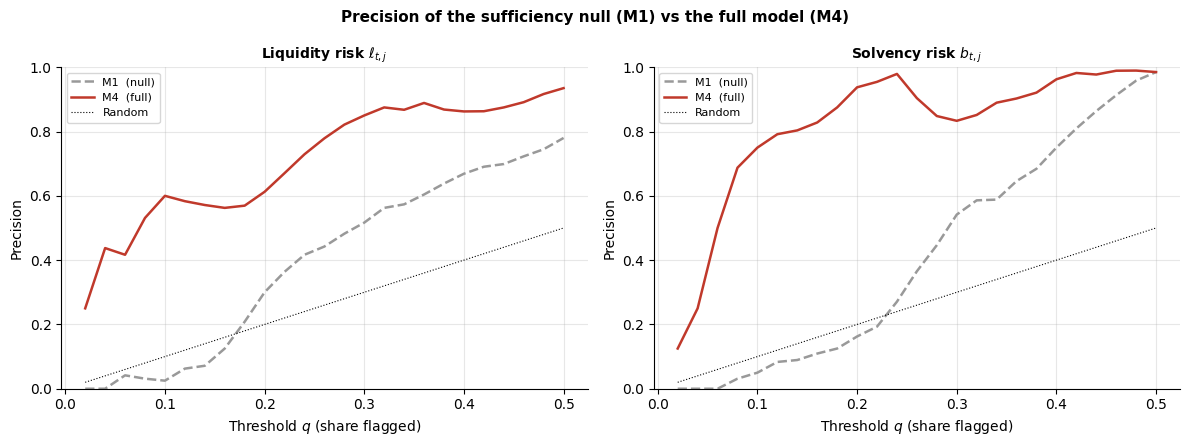

Saved: precision_null_vs_full.pdf


In [32]:
def precision_curve(y_te, rows, label, ax):
    qs = np.arange(0.02, 0.51, 0.02)
    for r, style in ((rows[0], dict(color='#999999', ls='--')),
                     (rows[-1], dict(color='#c0392b', ls='-'))):
        if r['y_pred_test'] is None:
            continue
        p = [top_decile_precision(y_te, r['y_pred_test'], q=q)['precision']
             for q in qs]
        ax.plot(qs, p, lw=1.8, label=r['model'].split(':')[0] +
                ('  (null)' if r is rows[0] else '  (full)'), **style)
    ax.plot(qs, qs, color='black', lw=0.8, ls=':', label='Random')
    ax.set_xlabel('Threshold $q$ (share flagged)')
    ax.set_ylabel('Precision')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
precision_curve(y_te_L, rows_L, 'Liquidity risk $\\ell_{t,j}$', axes[0])
precision_curve(y_te_S, rows_S, 'Solvency risk $b_{t,j}$',      axes[1])
fig.suptitle('Precision of the sufficiency null (M1) vs the full model (M4)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('precision_null_vs_full.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: precision_null_vs_full.pdf')

### PR curves

Same metric as Appendix D, applied to pool-day rankings rather than to days. Positives are the top decile of realized stress, so the random benchmark is 0.10 for both PR-AUC and top-decile precision.

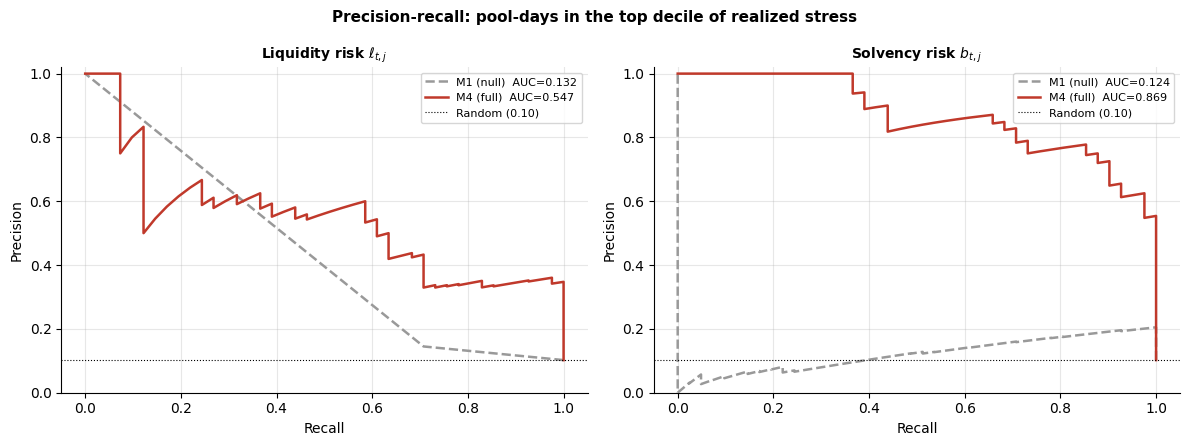

Saved: pr_curve_null_vs_full.pdf


In [33]:
# ── PR curves: the null (M1) against the full model (M4) ──────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (y_te, rows, lab) in zip(
        axes, [(y_te_L, rows_L, 'Liquidity risk $\\ell_{t,j}$'),
               (y_te_S, rows_S, 'Solvency risk $b_{t,j}$')]):
    for r, st in ((rows[0],  dict(color='#999999', ls='--')),
                  (rows[-1], dict(color='#c0392b', ls='-'))):
        if r['y_pred_test'] is None:
            continue
        pa = pr_auc(y_te, r['y_pred_test'])
        if pa['curve'] is None:
            continue
        prec, rec = pa['curve']
        tag = 'null' if r is rows[0] else 'full'
        ax.plot(rec, prec, lw=1.8,
                label=f"{r['model'].split(':')[0]} ({tag})  "
                      f"AUC={pa['pr_auc']:.3f}", **st)
        base = pa['baseline']
    ax.axhline(base, color='black', lw=0.8, ls=':',
               label=f'Random ({base:.2f})')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(lab, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.02); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Precision-recall: pool-days in the top decile of realized stress',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('pr_curve_null_vs_full.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: pr_curve_null_vs_full.pdf')

## 12. Reporting checklist

- [ ] M1 uses exactly the published statistics — check `M1_COLS` printed no warning
- [ ] Clark–West is reported one-sided; state this in the table note
- [ ] For liquidity, M3 vs M4 should *not* reject — report it, do not hide it
- [ ] Diebold–Mariano used only for OLS vs RF, never for the nested comparisons
- [ ] Top-decile baseline (0.10) stated so the lift is interpretable
- [ ] Say explicitly that pool-days are ranked across the panel: with two crypto pools per date a within-date ranking is a coin flip, so the referee's "ranking pools" is implemented as ranking pool-days

**Sentence for Section 6.3**, once the numbers are in:

> A natural null is that the pool-level statistics the protocol itself
> publishes are a sufficient statistic for systemic risk. We reject it. The
> collateral factor and utilization ratio explain 23.6% of out-of-sample
> variation in liquidity risk, against 86.8% for the full model, and a
> Clark--West test of the nested comparison rejects sufficiency at
> $p<0.001$. The gap is not confined to average fit: of the pool-days the
> published statistics flag as most at risk, only [X]% are genuinely in the
> top decile of realized stress, against [Y]% for the reconstructed network.

In [34]:
# %% [markdown]
# # Part III — Decision-relevant magnitudes
#
# Append after `cw_L, pr_L = test_table(...)` in `predictive_tests_STANDALONE.ipynb`.
# Needs only: `final_updated`, `features`, `break_date`, `rows_L`, `rows_S`,
# `y_te_L`, `y_te_S`, and the settings from Part II cell 33.
#
# Part II answers "does the network model predict better". Part III answers the
# referee's actual question, "why do these quantities matter", in three units a
# finance reader values:
#
# 1. **Dollar monitoring error** — how much stress the published dashboard
#    misstates, in millions, on an average and on a stressed pool-day.
# 2. **Alert budget** — how wide the net must be to catch a given share of
#    stressed pool-days.
# 3. **Tail calibration** — whether the dashboard is merely noisy, or
#    systematically understates the worst days.
#
# Cell 5 is optional. It re-runs the nested comparison without variable
# selection, which makes the Clark–West nesting assumption exactly true.

# %%
# ── 1. Align the pool asset scale to the test sample ─────────────────────
# build_sample() drops every column except the predictors, so the dollar
# scale has to be rebuilt by repeating its filters in the same order. The
# assertion at the end is the safety net: if the reconstruction drifted by
# even one row it fails loudly rather than reporting wrong dollars.

SCALE_COL = 'assets'          # pool total assets, the denominator of both outcomes


def aligned_scale(target_col, assets_sel, shock, add_fe_wbtc, y_tr, y_te,
                  scale_col=SCALE_COL,
                  group_keys=('pool_own', 'pool_centrality', 'pool_cross',
                              'collaterals_network', 'collaterals_financial')):
    """Return the scale variable for the test rows, indexed like y_te."""
    df = final_updated[
        (final_updated['date']             >= break_date) &
        (final_updated['size']             == shock) &
        (final_updated['shockAsset'].isin(assets_sel)) &
        (final_updated['health_threshold'] == HEALTH_THRESHOLD)
    ].copy()

    if add_fe_wbtc:
        df['fe_WBTC'] = (df['shockAsset'] == 'WBTC').astype(float)

    cols = [v for g in group_keys for v in features.get(g, [])]
    cols = list(dict.fromkeys(cols))
    if add_fe_wbtc:
        cols += ['fe_WBTC']
    cols = [v for v in cols if v in df.columns]

    keepcols = cols + [target_col, 'date']
    if scale_col not in df.columns:
        raise KeyError(f'{scale_col} not in final_updated')

    sub = df[keepcols + [scale_col]].copy()
    sub = sub[sub[keepcols].notna().all(axis=1)].reset_index(drop=True)
    sub = sub[sub['date'].values <= pd.Timestamp(TEST_END_DATE)]

    n_test  = int(len(sub) * TEST_SIZE)
    n_train = len(sub) - n_test

    y_rebuilt = sub[target_col]
    assert len(y_rebuilt) == len(y_tr) + len(y_te), (
        f'row count mismatch: rebuilt {len(y_rebuilt)}, '
        f'build_sample {len(y_tr) + len(y_te)}')
    np.testing.assert_allclose(
        y_rebuilt.iloc[n_train:].values, np.asarray(y_te, float),
        rtol=1e-10, atol=1e-12,
        err_msg='test-set target does not match build_sample — alignment broken')

    s = sub[scale_col].iloc[n_train:]
    s.index = y_te.index
    return s


scale_te_L = aligned_scale('shareT_pool', ['ETH', 'WBTC'], 0.50, False,
                           y_tr_L, y_te_L)
scale_te_S = aligned_scale('share_B',     ['ETH', 'WBTC'], 0.50, True,
                           y_tr_S, y_te_S)
print(f'liquidity: {len(scale_te_L)} test rows, '
      f'mean pool assets ${scale_te_L.mean()/1e6:,.0f}m')
print(f'solvency:  {len(scale_te_S)} test rows, '
      f'mean pool assets ${scale_te_S.mean()/1e6:,.0f}m')

# %%
# ── 2. The three indicators ──────────────────────────────────────────────


def dollar_error(y, pred, scale, q=0.10):
    """Prediction error in dollars, overall and on the most stressed pool-days.

    The outcomes are shares of pool assets, so multiplying the error by the
    pool's assets converts a fit statistic into the quantity a risk manager
    would misjudge by. `q` selects the top decile of REALIZED stress, which is
    where a monitoring error is costly.
    """
    y     = np.asarray(y, float)
    pred  = np.asarray(pred, float)
    scale = np.asarray(scale, float)

    err_usd = np.abs(y - pred) * scale
    tail    = y >= np.quantile(y, 1 - q)

    return dict(
        mae_usd_all   = err_usd.mean(),
        mae_usd_tail  = err_usd[tail].mean(),
        realized_tail = (y[tail] * scale[tail]).mean(),
        rel_err_tail  = err_usd[tail].mean() / (y[tail] * scale[tail]).mean(),
        n_tail        = int(tail.sum()),
    )


def alert_budget(y, pred, targets=(0.50, 0.80, 0.90), q=0.10):
    """Share of pool-days that must be flagged to catch `targets` of the tail.

    Precision at a fixed threshold and recall at that same threshold coincide
    when the flagged and realized sets are the same size, so precision alone
    cannot answer "how wide must the net be". This inverts the question: fix
    the recall you want, report the alert budget it costs.
    """
    y    = np.asarray(y, float)
    pred = np.asarray(pred, float)
    n    = len(y)

    pos = y >= np.quantile(y, 1 - q)
    n_pos = int(pos.sum())
    if n_pos == 0:
        return {f'budget_at_{int(t*100)}': np.nan for t in targets}

    order = np.argsort(-pred)
    hits  = np.cumsum(pos[order])
    recall = hits / n_pos

    out = {}
    for t in targets:
        idx = np.argmax(recall >= t) if (recall >= t).any() else None
        out[f'budget_at_{int(t*100)}'] = (idx + 1) / n if idx is not None else np.nan
    out['n_pos'] = n_pos
    return out


def tail_calibration(y, pred, qs=(0.10, 0.05)):
    """Mean predicted over mean realized stress, within the realized tail.

    A ratio near 1 means the model is noisy but unbiased in the tail. A ratio
    well below 1 means it systematically understates the worst days, which is
    a different and more serious failure for a risk dashboard than low R^2.

    Note that some shrinkage toward the mean is mechanical for any regression,
    so interpret the M1 ratio relative to the M4 ratio rather than against 1.
    """
    y    = np.asarray(y, float)
    pred = np.asarray(pred, float)

    out = {}
    for q in qs:
        tail = y >= np.quantile(y, 1 - q)
        out[f'ratio_top{int(q*100)}'] = pred[tail].mean() / y[tail].mean()
    return out


def magnitude_table(rows, y_te, scale_te, label):
    recs = []
    for r in rows:
        if r['y_pred_test'] is None:
            continue
        p = r['y_pred_test']
        d = dollar_error(y_te, p, scale_te)
        b = alert_budget(y_te, p)
        c = tail_calibration(y_te, p)
        recs.append({
            'model':        r['model'].split(':')[0],
            'test_R2':      r['test_r2'],
            'MAE_$m_all':   d['mae_usd_all'] / 1e6,
            'MAE_$m_tail':  d['mae_usd_tail'] / 1e6,
            'rel_err_tail': d['rel_err_tail'],
            'budget_80%':   b['budget_at_80'],
            'budget_90%':   b['budget_at_90'],
            'calib_top10':  c['ratio_top10'],
        })
    df = pd.DataFrame(recs)

    print(f"\n{'='*84}\n  {label} — decision-relevant magnitudes\n{'='*84}")
    print(df.to_string(index=False, formatters={
        'test_R2':      '{:.3f}'.format,
        'MAE_$m_all':   '{:,.1f}'.format,
        'MAE_$m_tail':  '{:,.1f}'.format,
        'rel_err_tail': '{:.1%}'.format,
        'budget_80%':   '{:.1%}'.format,
        'budget_90%':   '{:.1%}'.format,
        'calib_top10':  '{:.2f}'.format,
    }))

    if len(df) >= 2:
        m1, m4 = df.iloc[0], df.iloc[-1]
        print(f"\n  Reading for the text ({label.lower()}):")
        print(f"    On the most stressed decile of pool-days, the published "
              f"statistics misstate stress by ${m1['MAE_$m_tail']:,.1f}m "
              f"({m1['rel_err_tail']:.0%} of realized), against "
              f"${m4['MAE_$m_tail']:,.1f}m ({m4['rel_err_tail']:.0%}) "
              f"for the reconstructed network.")
        print(f"    To catch 80% of those pool-days, the published statistics "
              f"require flagging {m1['budget_80%']:.0%} of pool-days, "
              f"against {m4['budget_80%']:.0%}.")
        print(f"    In the realized top decile the published statistics "
              f"predict {m1['calib_top10']:.2f} of realized stress, "
              f"against {m4['calib_top10']:.2f}.")
    return df


mag_L = magnitude_table(rows_L, y_te_L, scale_te_L, 'LIQUIDITY RISK')
mag_S = magnitude_table(rows_S, y_te_S, scale_te_S, 'SOLVENCY RISK')

# %%
# ── 3. Forecast encompassing ─────────────────────────────────────────────
# Clark-West says the large model predicts better. Encompassing says the
# small model contributes nothing once the large one is available, which is
# the sufficiency claim stated directly. Regress realized stress on both
# predictions: under M4 encompassing M1, the weight on M1 is zero.


def encompassing(y, pred_small, pred_large, maxlags=HAC_MAXLAGS):
    X = pd.DataFrame({'pred_small': np.asarray(pred_small, float),
                      'pred_large': np.asarray(pred_large, float)})
    m = sm.OLS(np.asarray(y, float), sm.add_constant(X)).fit(
        cov_type='HAC', cov_kwds={'maxlags': maxlags})
    return dict(w_small=float(m.params['pred_small']),
                p_small=float(m.pvalues['pred_small']),
                w_large=float(m.params['pred_large']),
                p_large=float(m.pvalues['pred_large']))


for rows, y_te, lab in ((rows_L, y_te_L, 'LIQUIDITY'),
                        (rows_S, y_te_S, 'SOLVENCY')):
    ok = [r for r in rows if r['y_pred_test'] is not None]
    if len(ok) < 2:
        continue
    e = encompassing(y_te, ok[0]['y_pred_test'], ok[-1]['y_pred_test'])
    print(f"\n{lab} — encompassing regression (M1 and M4 predictions)")
    print(f"  weight on M1 = {e['w_small']:+.3f}  (p = {e['p_small']:.3f})")
    print(f"  weight on M4 = {e['w_large']:+.3f}  (p = {e['p_large']:.3f})")
    print("  M4 encompasses M1 if the first weight is indistinguishable "
          "from zero and the second from one.")

# %%
# ── 4. LaTeX block for the magnitudes ────────────────────────────────────


def latex_magnitudes(mag_L, mag_S):
    nl = r' \\'
    lines = [
        r'\begin{table}[ht]', r'\centering', r'\begin{threeparttable}',
        r'\caption{Economic magnitude of the monitoring gap.}',
        r'\label{tab:magnitudes}', r'\footnotesize',
        r'\begin{tabular}{lrrrrrr}', r'\toprule',
        r'& \multicolumn{3}{c}{Liquidity risk ($\ell_{t,j}$)}'
        r'& \multicolumn{3}{c}{Solvency risk ($b_{t,j}$)}' + nl,
        r'\cmidrule(lr){2-4}\cmidrule(lr){5-7}',
        r'Model & MAE (\$m) & Alert budget & Tail calib. '
        r'& MAE (\$m) & Alert budget & Tail calib.' + nl,
        r'\midrule',
    ]
    names = {'M1': 'M1: Asset side (null)',
             'M2': r'M2: $+$ Pool features',
             'M3': r'M3: $+$ Collateral network',
             'M4': r'\textbf{M4: $+$ User features (full)}'}

    L, S = mag_L.set_index('model'), mag_S.set_index('model')
    for k in ['M1', 'M2', 'M3', 'M4']:
        cells = []
        for tab in (L, S):
            if k not in tab.index:
                cells += ['---'] * 3
                continue
            r = tab.loc[k]
            cells += [f"{r['MAE_$m_tail']:,.1f}",
                      f"{r['budget_80%']*100:.0f}\\%",
                      f"{r['calib_top10']:.2f}"]
        lines.append(names.get(k, k) + ' & ' + ' & '.join(cells) + nl)

    lines += [
        r'\bottomrule', r'\end{tabular}', r'\begin{tablenotes}[flushleft]',
        r'\footnotesize',
        r'\item \textit{Notes}: All columns are computed on the held-out test '
        r'set. MAE (\$m) is the mean absolute prediction error in millions of '
        r'dollars on the top decile of realized stress, obtained by scaling '
        r'the predicted share by pool assets. Alert budget is the share of '
        r'test pool-days that must be flagged, in order of predicted risk, to '
        r'capture 80\% of the pool-days in the top decile of realized stress; '
        r'a perfect ranker needs 8\%. Tail calibration is mean predicted '
        r'over mean realized stress within the realized top decile, so a '
        r'value below one indicates systematic understatement of the worst '
        r'days. M1 contains the pool-level statistics the protocol publishes.',
        r'\end{tablenotes}', r'\end{threeparttable}', r'\end{table}',
    ]
    return '\n'.join(lines)


print(latex_magnitudes(mag_L, mag_S))

# %% [markdown]
# ## 5. Optional: Clark–West on exactly nested specifications
#
# Clark–West assumes the small model's parameter space is nested in the large
# one. Your candidate sets are nested, but LASSO and trimming re-select at
# each step, so the *selected* sets need not be: M2 can drop a variable M1
# retained. A referee who knows the test will raise this.
#
# Two ways out. Either state in the table note that nesting holds in the
# candidate space, or run the comparison with selection switched off, which
# makes nesting exact. The cell below does the latter. Report it as a check
# and keep the selected-model version as the headline, since that is the
# specification the paper uses elsewhere.

# %%
def run_plain_ols(X_tr, y_tr, X_te, y_te, cols):
    """OLS on the full candidate set — no LASSO, no trimming, exact nesting."""
    m = sm.OLS(y_tr, sm.add_constant(X_tr[cols])).fit(
        cov_type='HAC', cov_kwds={'maxlags': HAC_MAXLAGS})
    pred = m.predict(sm.add_constant(X_te[cols], has_constant='add'))
    res  = y_te - pred
    ss   = ((y_te - y_te.mean()) ** 2).sum()
    return dict(model='', test_r2=1 - (res ** 2).sum() / ss if ss > 0 else np.nan,
                n_vars=len(cols),
                y_pred_test=pd.Series(pred, index=y_te.index))


def cw_exactly_nested(X_tr, X_te, y_tr, y_te, add_fe_wbtc, label):
    specs = nested_specs(X_tr, add_fe_wbtc)
    fitted = []
    for name, cols in specs:
        r = run_plain_ols(X_tr, y_tr, X_te, y_te, cols)
        r['model'] = name
        fitted.append(r)

    recs = []
    pairs = [(fitted[i], fitted[i + 1]) for i in range(len(fitted) - 1)]
    pairs.append((fitted[0], fitted[-1]))
    for small, large in pairs:
        cw = clark_west(y_te, small['y_pred_test'], large['y_pred_test'])
        recs.append({
            'comparison': f"{small['model'].split(':')[0]} vs "
                          f"{large['model'].split(':')[0]}",
            'R2_small': small['test_r2'], 'R2_large': large['test_r2'],
            'dR2': large['test_r2'] - small['test_r2'],
            'CW_t': cw['t_stat'], 'CW_p': cw['p_value'],
        })
    df = pd.DataFrame(recs)
    print(f"\n{label} — Clark-West, no variable selection (exact nesting)")
    print(df.to_string(index=False, formatters={
        'R2_small': '{:.3f}'.format, 'R2_large': '{:.3f}'.format,
        'dR2': '{:+.3f}'.format, 'CW_t': '{:.2f}'.format,
        'CW_p': '{:.4f}'.format}))
    return df


cw_exact_L = cw_exactly_nested(X_tr_L, X_te_L, y_tr_L, y_te_L, False, 'LIQUIDITY')
cw_exact_S = cw_exactly_nested(X_tr_S, X_te_S, y_tr_S, y_te_S, True,  'SOLVENCY')

# %% [markdown]
# ## Reporting checklist, Part III
#
# - [ ] `SCALE_COL` is the same denominator as the outcome. Both `shareT_pool`
#       and `share_B` divide by `assets`, so `assets` is correct. Change it if
#       you switch to `total_assets`.
# - [ ] The alignment assertion passed, so the dollar figures are on the right
#       rows.
# - [ ] Alert budget: the floor is the target recall times the tail share, so
#       8% for 80% of the top decile, not 10%. Quote the floor so the number
#       is interpretable: 30% is nearly four times the minimum workload.
# - [ ] Tail calibration below one is understatement. Say which direction the
#       dashboard errs, not just that it errs.
# - [ ] Say that pool-days, not pools, are ranked. With two crypto pools per
#       date a within-date ranking is a coin flip.
# - [ ] If the exact-nesting Clark-West in cell 5 agrees with the selected-model
#       version, one sentence in the table note is enough. If it disagrees,
#       report the exactly nested version.

liquidity: 401 test rows, mean pool assets $459m
solvency:  401 test rows, mean pool assets $459m

  LIQUIDITY RISK — decision-relevant magnitudes
model test_R2 MAE_$m_all MAE_$m_tail rel_err_tail budget_80% budget_90% calib_top10
   M1   0.236       19.0        36.5        39.8%      57.1%      59.4%        0.60
   M2   0.523       14.3        18.8        20.4%      46.6%      48.4%        0.81
   M3   0.869        7.5        10.2        11.1%      25.2%      29.7%        0.95
   M4   0.868        7.7        13.5        14.7%      23.9%      26.7%        0.99

  Reading for the text (liquidity risk):
    On the most stressed decile of pool-days, the published statistics misstate stress by $36.5m (40% of realized), against $13.5m (15%) for the reconstructed network.
    To catch 80% of those pool-days, the published statistics require flagging 57% of pool-days, against 24%.
    In the realized top decile the published statistics predict 0.60 of realized stress, against 0.99.

  SOLVENC